# Deep Hedging under Transaction Costs

**Chapter 21: Reinforcement Learning for Execution and Hedging**

## Purpose

Black-Scholes says a short call can be replicated exactly by holding
$\Delta = \Phi(d_1)$ of the underlying and rebalancing continuously. Two of
those words do the damage. *Continuously* is not available: a hedge is
adjusted at discrete times, and between adjustments the position is wrong.
*Exactly* assumes rebalancing is free, and it is not: every adjustment crosses
a spread. Under both frictions perfect replication is impossible, and the
question changes from how to replicate to what shape of P&L to accept.

Deep hedging asks that question directly. Instead of deriving a hedge from a
replication argument and then apologising for the frictions, it fixes a risk
measure over terminal P&L and trains a network to minimise it under the
frictions as they are. This notebook trains such a hedger, and compares it
against the analytical delta hedge, a friction-aware analytical rule, a
from-scratch implementation of the same idea, and a tabular value-based
baseline - all on identical price paths and one P&L convention.

## Learning objectives

After working through this notebook you will be able to:

- State the self-financing P&L of a hedged short option under proportional
  transaction costs, and verify a library's implementation of it against your
  own rather than assuming they agree.
- Train a hedging policy against an expected-shortfall objective with
  `pfhedge`, and explain what changes about the resulting hedge when the
  objective is a tail measure rather than a variance.
- Implement the same idea from scratch in PyTorch - the rollout, the
  differentiable P&L, the tail loss - and check it against the library on the
  same paths.
- Select a training seed on a validation set before looking at the evaluation
  set, and say what the selection would otherwise cost you.
- Compare hedging strategies on the shape of their P&L distribution rather
  than on a mean, using an empirical cumulative distribution function that
  keeps the tails a histogram hides.

## Book reference

Section 21.6, *Application III - Deep hedging for derivatives*.

## Prerequisites

- Chapter 19 on risk measures, for value at risk and expected shortfall.
- `pfhedge`, a main dependency of the project.
- A CUDA device if you want to reproduce the committed numbers. Seeded
  PyTorch training is device-dependent, so a run on a different device, or a
  different CUDA or PyTorch build, should be expected to produce different
  P&L. The setup cell prints the versions the committed run used.

## Setup

In [1]:
"""Deep hedging under transaction costs - a learned hedge against analytical and tabular baselines."""

import platform
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

# pfhedge's docstrings raise a SyntaxWarning on import under Python 3.14 and say
# nothing about this run. Convergence, overflow and invalid-value warnings stay
# visible: they report conditions the hedging results depend on.
warnings.filterwarnings("ignore", category=SyntaxWarning, module="pfhedge")

import pfhedge
from pfhedge.instruments import EuropeanOption, HestonStock
from pfhedge.nn import (
    BlackScholes,
    ExpectedShortfall,
    Hedger,
    MultiLayerPerceptron,
    WhalleyWilmott,
)

import utils  # noqa: F401  - sets the Plotly renderer so figures carry a static PNG
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_plotly_with_alt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(
    f"python {platform.python_version()} | pfhedge {pfhedge.__version__} | "
    f"torch {torch.__version__}"
)
print(
    f"cuda build {torch.version.cuda} | device "
    + (torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
)

python 3.14.3 | pfhedge 0.22.0 | torch 2.10.0+cu128
cuda build 12.8 | device NVIDIA GeForce RTX 3090


In [2]:
N_PATHS = 10_000  # paths in each of the training, validation and evaluation sets
N_STEPS = 20  # rebalancing opportunities between inception and expiry
MATURITY = 30 / 365  # option life, in years
SPOT = 100.0  # initial price of the underlying, used only to report P&L in currency
STRIKE = 100.0  # strike of the call being hedged; at the money at inception
COST_BPS = 10  # proportional transaction cost, in basis points of notional traded
N_EPOCHS = 200  # optimiser passes over the training paths
EXPECTED_SHORTFALL_Q = 0.05  # tail probability the training objective averages over
HESTON_V0_VOL = 0.20  # initial and long-run volatility of the Heston process
HESTON_KAPPA = 1.5  # speed at which variance reverts to its long-run level
HESTON_SIGMA = 0.35  # volatility of the variance process
HESTON_RHO = -0.7  # correlation between the price and variance shocks
WHALLEY_WILMOTT_RISK_AVERSION = 1.0  # risk aversion setting the width of the no-trade band
TRAINING_SEEDS = [42, 314, 2718]  # one training run per seed
VALIDATION_SEED = 777  # paths the training seed is selected on
EVAL_SEED = 999  # paths every reported number is computed on
QLBS_TRAIN_SEED = 10_999  # paths the tabular baseline is trained on
SEED = 42

In [3]:
set_global_seeds(SEED)

# Everything inside pfhedge works in units of the initial spot, so the strike is
# expressed the same way and P&L is scaled back to currency at the end.
COST_RATE = COST_BPS / 10_000
PFHEDGE_STRIKE = STRIKE / SPOT
DT = MATURITY / N_STEPS

### What the settings decide

`N_STEPS` and `COST_BPS` are the two that create the problem. With continuous,
free rebalancing the delta hedge is exact and there is nothing to learn. Twenty
rebalancing dates over a month leave the hedge wrong between them, and ten
basis points on every adjustment means that correcting the error more often
costs more than the error does. Every method below is a different answer to
where that balance sits.

In [4]:
display(
    Markdown(f"""
- **Instrument**: a European call struck at {STRIKE:,.0f} on an underlying starting at
  {SPOT:,.0f}, expiring in {MATURITY * 365:.0f} days. The notebook is short the option and
  hedges it.
- **Rebalancing**: {N_STEPS} dates, so one adjustment every
  {MATURITY * 365 / N_STEPS:.1f} days.
- **Transaction cost**: {COST_BPS} basis points of the notional traded, charged on every
  adjustment in both directions.
- **Objective**: expected shortfall at {EXPECTED_SHORTFALL_Q:.0%}, the average P&L over the
  worst {EXPECTED_SHORTFALL_Q:.0%} of paths.
- **Paths**: {N_PATHS:,} in each of three independent sets - one to train on, one to select
  the training seed on, one to report every number from.
""")
)


- **Instrument**: a European call struck at 100 on an underlying starting at
  100, expiring in 30 days. The notebook is short the option and
  hedges it.
- **Rebalancing**: 20 dates, so one adjustment every
  1.5 days.
- **Transaction cost**: 10 basis points of the notional traded, charged on every
  adjustment in both directions.
- **Objective**: expected shortfall at 5%, the average P&L over the
  worst 5% of paths.
- **Paths**: 10,000 in each of three independent sets - one to train on, one to select
  the training seed on, one to report every number from.


## 1. The problem, stated as a P&L

The notebook is short one call and holds $\delta_t$ units of the underlying
over each interval. Nothing is added to or taken from the position after
inception, so the terminal P&L of the hedged book is

$$\text{P\&L} = \underbrace{\sum_{t} \delta_t (S_{t+1} - S_t)}_{\text{hedge gains}}
  \; - \; \underbrace{c \sum_{t} |\delta_t - \delta_{t-1}| \, S_t}_{\text{transaction costs}}
  \; - \; \underbrace{\max(S_T - K, 0)}_{\text{option payoff}}$$

with $c$ the proportional cost rate and $\delta_{-1} = 0$. This is called
**self-financing**: the hedge pays for itself out of its own gains, and the
only external cash flow is the payoff owed at expiry.

A perfect hedge would make this quantity a constant. Under discrete
rebalancing and costs it is a distribution, and the whole subject is which
distribution to prefer.

### The objective: expected shortfall

**Expected shortfall** at level $q$, also called conditional value at risk, is
the average P&L over the worst $q$ of the paths:

$$\mathrm{ES}_q = -\,\mathbb{E}\!\left[\,\text{P\&L} \mid \text{P\&L} \le F^{-1}(q)\,\right]$$

Minimising it is not the same as minimising variance. Variance charges equally
for a good surprise and a bad one; expected shortfall looks only at the losing
tail, and is indifferent between two hedges whose worst five per cent of
outcomes agree, however different the rest of their distributions are.

## 2. The market: a stochastic-volatility underlying

The underlying follows a **Heston** process: the price has a volatility that
is itself random, mean-reverting, and negatively correlated with the price.

$$dS_t = \sqrt{v_t}\,S_t \, dW^S_t, \qquad
dv_t = \kappa(\theta - v_t)\,dt + \sigma \sqrt{v_t}\, dW^v_t, \qquad
d\langle W^S, W^v\rangle_t = \rho \, dt$$

The choice matters for what the comparison means. Black-Scholes delta assumes
a constant volatility, so on Heston paths it is not merely discretised, it is
also using the wrong model. That gap is part of what a learned hedge can pick
up, and it is why the analytical baselines here are given the realised
volatility of each path rather than a single number: without that they would
be losing on a handicap rather than on the frictions.

In [5]:
def build_option(seed: int, n_paths: int) -> EuropeanOption:
    """Simulate one independent set of Heston paths and the call written on them."""
    torch.manual_seed(seed)
    stock = HestonStock(
        kappa=HESTON_KAPPA,
        theta=HESTON_V0_VOL**2,
        sigma=HESTON_SIGMA,
        rho=HESTON_RHO,
        cost=COST_RATE,
        dt=DT,
        device=DEVICE,
    )
    option = EuropeanOption(stock, maturity=MATURITY, strike=PFHEDGE_STRIKE).to(device=DEVICE)
    option.simulate(n_paths=n_paths)
    return option


train_options = {seed: build_option(seed, N_PATHS) for seed in TRAINING_SEEDS}
validation_option = build_option(VALIDATION_SEED, N_PATHS)
eval_option = build_option(EVAL_SEED, N_PATHS)

### What the paths look like

The left panel shows where the price ends up relative to the strike, which
decides how much of the option finishes in the money. The right panel shows the
volatility over the life of the option: it starts at its long-run level and
fans out, and a hedge that reads it can act on that.

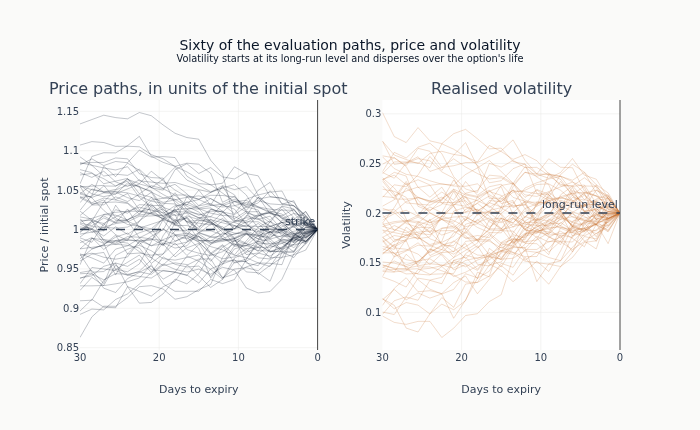

In [6]:
eval_spot = eval_option.ul().spot.detach().cpu().numpy()
eval_vol = eval_option.ul().volatility.detach().cpu().numpy()
time_days = np.arange(eval_spot.shape[1]) * DT * 365

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Price paths, in units of the initial spot", "Realised volatility"),
    horizontal_spacing=0.12,
)
for path in range(60):
    fig.add_trace(
        go.Scatter(
            x=time_days,
            y=eval_spot[path],
            line=dict(color=COLORS["blue"], width=0.7),
            opacity=0.35,
            showlegend=False,
            hoverinfo="skip",
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=time_days,
            y=eval_vol[path],
            line=dict(color=COLORS["copper"], width=0.7),
            opacity=0.35,
            showlegend=False,
            hoverinfo="skip",
        ),
        row=1,
        col=2,
    )
fig.add_hline(
    y=PFHEDGE_STRIKE,
    line=dict(color=COLORS["neutral"], width=1.5, dash="dash"),
    annotation_text="strike",
    row=1,
    col=1,
)
fig.add_hline(
    y=HESTON_V0_VOL,
    line=dict(color=COLORS["neutral"], width=1.5, dash="dash"),
    annotation_text="long-run level",
    row=1,
    col=2,
)
fig.update_yaxes(title_text="Price / initial spot", row=1, col=1)
fig.update_yaxes(title_text="Volatility", row=1, col=2)
fig.update_xaxes(title_text="Days to expiry", autorange="reversed", row=1, col=1)
fig.update_xaxes(title_text="Days to expiry", autorange="reversed", row=1, col=2)
fig.update_layout(
    title=(
        "Sixty of the evaluation paths, price and volatility"
        "<br><sup>Volatility starts at its long-run level and disperses over the option's "
        "life</sup>"
    ),
    height=430,
)
show_plotly_with_alt(
    fig,
    "Two panels of sixty simulated Heston paths over the option's life, drawn against days to expiry. Left: price paths in units of the initial spot, with a dashed line at the strike. Right: the realised volatility of the same paths, fanning out from a dashed line at its long-run level.",
)

## 3. One P&L convention, checked two ways

Five hedging methods are compared below and three of them are computed outside
`pfhedge`. The comparison is only meaningful if every method's P&L is measured
the same way, and "the same way" is a claim about two implementations that has
to be checked rather than asserted.

The check is direct: take the Black-Scholes delta hedge, ask `pfhedge` for both
the positions it held and the P&L it computed, then recompute the P&L from
those positions with the formula from section 1 and compare.

In [7]:
def hedging_pnl(prices: np.ndarray, positions: np.ndarray, strike: float) -> np.ndarray:
    """Self-financing P&L of a hedged short call, one value per path."""
    if positions.shape != prices[:, :-1].shape:
        raise ValueError(f"Expected positions shape {prices[:, :-1].shape}, got {positions.shape}")
    previous = np.concatenate([np.zeros((positions.shape[0], 1)), positions[:, :-1]], axis=1)
    hedge_gains = (positions * np.diff(prices, axis=1)).sum(axis=1)
    costs = (np.abs(positions - previous) * prices[:, :-1]).sum(axis=1) * COST_RATE
    return hedge_gains - costs - np.maximum(prices[:, -1] - strike, 0.0)


def hedging_pnl_torch(prices: torch.Tensor, positions: torch.Tensor, strike: float) -> torch.Tensor:
    """Differentiable version of :func:`hedging_pnl`, used inside the training loop."""
    previous = torch.cat([torch.zeros_like(positions[:, :1]), positions[:, :-1]], dim=1)
    hedge_gains = (positions * (prices[:, 1:] - prices[:, :-1])).sum(dim=1)
    costs = ((positions - previous).abs() * prices[:, :-1]).sum(dim=1) * COST_RATE
    return hedge_gains - costs - torch.relu(prices[:, -1] - strike)

In [8]:
bs_model = BlackScholes(eval_option).to(DEVICE)
bs_hedger = Hedger(bs_model, bs_model.inputs()).to(DEVICE)

library_pnl = bs_hedger.compute_pl(eval_option).detach().cpu().numpy()
own_pnl = hedging_pnl(
    eval_spot,
    bs_hedger.compute_hedge(eval_option).detach().cpu().numpy()[:, 0, :-1],
    PFHEDGE_STRIKE,
)
convention_gap = float(np.abs(library_pnl - own_pnl).max())
assert convention_gap < 1e-5, f"P&L conventions disagree by {convention_gap}"

display(
    Markdown(f"""
The two implementations agree to **{convention_gap:.2e}** in units of the initial spot, over
all {N_PATHS:,} evaluation paths. Every P&L below is therefore comparable whichever code
produced it, and the from-scratch hedger in section 6 can be trained against the second
implementation without leaving the comparison.
""")
)


The two implementations agree to **1.63e-08** in units of the initial spot, over
all 10,000 evaluation paths. Every P&L below is therefore comparable whichever code
produced it, and the from-scratch hedger in section 6 can be trained against the second
implementation without leaving the comparison.


### Reporting statistics

Four numbers describe each P&L distribution: its mean, its standard deviation,
the expected shortfall at the objective's own tail probability, and the single
worst path. The last two are what a tail-risk objective is aimed at; the first
two are what a variance-based objective would be aimed at, and they are here so
the difference is visible.

In [9]:
def pnl_stats(pnl: np.ndarray) -> dict:
    """Mean, dispersion and two tail statistics of a P&L distribution, in currency."""
    scaled = np.asarray(pnl) * SPOT
    cutoff = np.percentile(scaled, 100 * EXPECTED_SHORTFALL_Q)
    return {
        "mean": float(np.mean(scaled)),
        "std": float(np.std(scaled)),
        "expected_shortfall": float(np.mean(scaled[scaled <= cutoff])),
        "worst_path": float(np.min(scaled)),
    }

## 4. Two analytical baselines

**Black-Scholes delta** holds $\Phi(d_1)$ units of the underlying at every
rebalancing date. It is the hedge that would be exact under continuous, free
rebalancing of a constant-volatility underlying, and it is the reference every
desk's hedge is described relative to. It knows nothing about the transaction
cost, so it pays whatever its own rebalancing schedule costs.

**Whalley-Wilmott** is the same idea made friction-aware. It derives, in the
limit of small costs, a band around the delta inside which trading is not worth
its cost: the hedge is left alone while it stays inside the band and moved to
the edge when it leaves. The width of the band grows with the cost rate and
shrinks with the risk-aversion parameter, so it is the analytical answer to the
same trade-off the learned hedgers are searching for numerically.

In [10]:
ww_criterion = ExpectedShortfall(EXPECTED_SHORTFALL_Q).to(DEVICE)
ww_model = WhalleyWilmott(eval_option, a=WHALLEY_WILMOTT_RISK_AVERSION).to(DEVICE)
ww_hedger = Hedger(ww_model, ww_model.inputs(), criterion=ww_criterion).to(DEVICE)

pnl = {
    "Black-Scholes delta": library_pnl,
    "Whalley-Wilmott": ww_hedger.compute_pl(eval_option).detach().cpu().numpy(),
}

## 5. The deep hedger

`pfhedge`'s `Hedger` wraps a network that maps a state to a position. The
state is four numbers - the log of the price over the strike (**log
moneyness**), the time left to expiry, the current volatility, and the position
held going in - and the whole rollout is differentiable, so the tail loss on
terminal P&L can be backpropagated to the network weights directly. Nothing in
the training references a delta, a replication argument or a pricing formula.

### Three seeds, and a selection made before the evaluation set is touched

A single training run is one draw from a distribution over initialisations and
path draws. Three runs are trained, each on its own set of paths, and the one
whose validation expected shortfall is the middle of the three is carried
forward. The validation paths are drawn for that choice and used for nothing
else, so every number reported below comes from a set of paths that took no
part in training and no part in deciding which trained run to report.

In [11]:
def build_deep_hedger() -> Hedger:
    """A four-input multilayer perceptron trained against the expected-shortfall criterion."""
    return Hedger(
        model=MultiLayerPerceptron(in_features=4, out_features=1),
        inputs=["log_moneyness", "time_to_maturity", "volatility", "prev_hedge"],
        criterion=ExpectedShortfall(EXPECTED_SHORTFALL_Q).to(DEVICE),
    ).to(DEVICE)

In [12]:
seed_runs = []
for seed in TRAINING_SEEDS:
    print(f"Training pfhedge deep hedger, seed {seed}...")
    seed_hedger = build_deep_hedger()
    seed_hedger.fit(train_options[seed], n_epochs=N_EPOCHS, n_paths=N_PATHS, verbose=False)
    validation_stats = pnl_stats(seed_hedger.compute_pl(validation_option).detach().cpu().numpy())
    seed_runs.append({"seed": seed, "hedger": seed_hedger, "validation": validation_stats})

Training pfhedge deep hedger, seed 42...


Training pfhedge deep hedger, seed 314...


Training pfhedge deep hedger, seed 2718...


In [13]:
seed_summary = pl.DataFrame(
    [
        {
            "Training seed": run["seed"],
            "Validation mean": round(run["validation"]["mean"], 4),
            "Validation std": round(run["validation"]["std"], 4),
            "Validation expected shortfall": round(run["validation"]["expected_shortfall"], 4),
            "Validation worst path": round(run["validation"]["worst_path"], 4),
        }
        for run in seed_runs
    ]
).sort("Training seed")

median_es = float(seed_summary["Validation expected shortfall"].median())
representative_seed = int(
    seed_summary.with_columns(
        (pl.col("Validation expected shortfall") - median_es).abs().alias("distance")
    ).sort("distance", "Training seed")["Training seed"][0]
)
deep_hedger = next(run["hedger"] for run in seed_runs if run["seed"] == representative_seed)
pnl["Deep hedging (pfhedge)"] = deep_hedger.compute_pl(eval_option).detach().cpu().numpy()

print(f"Carried forward: seed {representative_seed}")
seed_summary

Carried forward: seed 314


Training seed,Validation mean,Validation std,Validation expected shortfall,Validation worst path
i64,f64,f64,f64,f64
42,-2.3103,1.5256,-6.0689,-9.9579
314,-2.3495,1.0786,-4.7369,-7.2952
2718,-2.3584,0.9091,-4.274,-5.8316


## 6. The same idea, from scratch

The library call above hides the three pieces that make deep hedging work, and
they are worth writing once. The network is an ordinary multilayer perceptron.
The rollout walks the paths step by step, feeding each position back in as an
input to the next. The loss is the expected shortfall of the terminal P&L
computed by the same function checked in section 3. Once those three exist,
training is a plain Adam loop.

It is trained and evaluated on the same Heston paths as everything else, so its
row in the comparison means what the other rows mean. Where it differs from the
`pfhedge` hedger is only in the details a library gets to choose: layer widths,
initialisation, the output nonlinearity, and how the tail of the loss is
estimated within a batch.

### The network

Three layers, and a sigmoid on the output. The sigmoid restricts the position
to $[0, 1]$, which is where the delta of a call lives; it is a constraint the
`pfhedge` network is not given, and it is the clearest structural difference
between the two.

In [14]:
class FromScratchHedger(nn.Module):
    """Maps (log moneyness, time to maturity, volatility, previous position) to a position."""

    def __init__(self, hidden_size: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid(),
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.net(features)

### The rollout

One position per rebalancing date, with the previous position fed forward. The
loop cannot be vectorised over time because the position at each date is an
input to the next, which is exactly what makes this a control problem rather
than a regression.

In [15]:
def rollout(model: nn.Module, spot: torch.Tensor, volatility: torch.Tensor) -> torch.Tensor:
    """Positions held over each interval, shaped (n_paths, n_steps)."""
    n_paths, n_times = spot.shape
    position = torch.zeros(n_paths, device=spot.device)
    positions = []
    for t in range(n_times - 1):
        features = torch.stack(
            [
                torch.log(spot[:, t] / PFHEDGE_STRIKE),
                torch.full_like(spot[:, t], MATURITY - t * DT),
                volatility[:, t],
                position,
            ],
            dim=1,
        )
        position = model(features).squeeze(1)
        positions.append(position)
    return torch.stack(positions, dim=1)


def expected_shortfall_loss(pnl: torch.Tensor) -> torch.Tensor:
    """Expected shortfall of a P&L tensor, as a loss to minimise."""
    cutoff = torch.quantile(pnl, EXPECTED_SHORTFALL_Q)
    tail = pnl[pnl <= cutoff]
    return -pnl.mean() if tail.numel() == 0 else -tail.mean()

### Training

Full-batch Adam on the same paths the representative `pfhedge` run was trained
on, for the same number of epochs.

In [16]:
torch.manual_seed(representative_seed)
scratch_model = FromScratchHedger().to(DEVICE)
optimizer = torch.optim.Adam(scratch_model.parameters(), lr=0.01)

scratch_train_option = train_options[representative_seed]
scratch_train_spot = scratch_train_option.ul().spot.to(DEVICE)
scratch_train_vol = scratch_train_option.ul().volatility.to(DEVICE)

training_loss = []
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
    loss = expected_shortfall_loss(
        hedging_pnl_torch(
            scratch_train_spot,
            rollout(scratch_model, scratch_train_spot, scratch_train_vol),
            PFHEDGE_STRIKE,
        )
    )
    loss.backward()
    optimizer.step()
    training_loss.append(float(loss.detach()))

print(f"From-scratch training complete over {N_EPOCHS} epochs")

From-scratch training complete over 200 epochs


In [17]:
scratch_model.eval()
with torch.no_grad():
    pnl["Deep hedging (from scratch)"] = (
        hedging_pnl_torch(
            eval_option.ul().spot.to(DEVICE),
            rollout(
                scratch_model,
                eval_option.ul().spot.to(DEVICE),
                eval_option.ul().volatility.to(DEVICE),
            ),
            PFHEDGE_STRIKE,
        )
        .cpu()
        .numpy()
    )

### The training curve

The loss is the expected shortfall of the training paths' P&L, so it falls as
the hedge protects the tail better. A curve that is still descending at the
last epoch means the budget, not the method, set where training stopped.

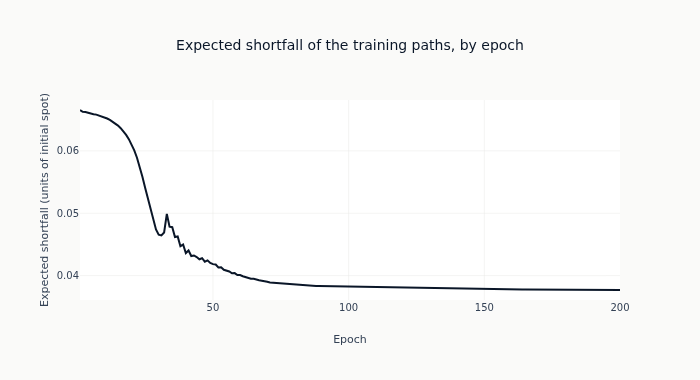

In [18]:
fig = go.Figure(
    go.Scatter(
        x=list(range(1, N_EPOCHS + 1)),
        y=training_loss,
        line=dict(color=COLORS["blue"], width=2),
    )
)
fig.update_layout(
    title="Expected shortfall of the training paths, by epoch",
    xaxis_title="Epoch",
    yaxis_title="Expected shortfall (units of initial spot)",
    height=380,
)
show_plotly_with_alt(
    fig,
    "A single line of the from-scratch hedger's training loss, the expected shortfall of the training paths' profit and loss, against the epoch number.",
)

## 7. A value-based baseline

Every hedger so far learns a position directly. A value-based method learns
what each position is *worth* in each state and then acts greedily on that.
The version here is a compact tabular Q-learner in the spirit of Halperin's
QLBS formulation: the state is a coarse grid over log moneyness, time and the
position currently held, the action is one of eleven positions between zero and
one, and the per-step reward is quadratic in the step's cost,

$$R(c) = -c - \lambda c^2$$

which penalises both the level of the cost and its dispersion. It is a
benchmark for intuition, not a reproduction of the paper: the reward is
mean-variance rather than the paper's, and the discretisation is coarse enough
to fit in one notebook section.

In [19]:
MONEYNESS_BINS = np.linspace(-0.3, 0.3, 7)
TIME_BINS = np.linspace(0, 1, 5)
HEDGE_LEVELS = np.linspace(0, 1, 11)
QLBS_RISK_AVERSION = 0.5
QLBS_LEARNING_RATE = 0.1
QLBS_DISCOUNT = 0.99


def state_index(spot_level: float, step: int, position_index: int) -> tuple[int, int, int]:
    """Bin a continuous state onto the tabular grid."""
    moneyness = np.clip(
        np.digitize(np.log(spot_level / PFHEDGE_STRIKE), MONEYNESS_BINS) - 1,
        0,
        len(MONEYNESS_BINS) - 1,
    )
    elapsed = np.clip(np.digitize(step * DT / MATURITY, TIME_BINS) - 1, 0, len(TIME_BINS) - 1)
    return (moneyness, elapsed, position_index)

Each path contributes one pass of temporal-difference updates. Exploration
decays over the paths, so the table is filled by random action early and
refined by the greedy action later.

In [20]:
def qlbs_update(q_table: np.ndarray, path: np.ndarray, exploration: float) -> None:
    """Apply tabular Q-learning updates along one price path, in place."""
    position_index = len(HEDGE_LEVELS) // 2
    for t in range(len(path) - 1):
        state = state_index(path[t], t, position_index)
        action = (
            np.random.randint(len(HEDGE_LEVELS))
            if np.random.random() < exploration
            else int(np.argmax(q_table[state]))
        )
        step_cost = COST_RATE * abs(HEDGE_LEVELS[action] - HEDGE_LEVELS[position_index]) * path[t]
        step_pnl = step_cost - HEDGE_LEVELS[action] * (path[t + 1] - path[t])
        reward = -step_pnl - QLBS_RISK_AVERSION * step_pnl**2

        if t < len(path) - 2:
            next_state = state_index(path[t + 1], t + 1, action)
            target = reward + QLBS_DISCOUNT * np.max(q_table[next_state])
        else:
            terminal = HEDGE_LEVELS[action] * path[-1] - max(path[-1] - PFHEDGE_STRIKE, 0.0)
            terminal -= COST_RATE * abs(HEDGE_LEVELS[action]) * path[-1]
            target = terminal - QLBS_RISK_AVERSION * terminal**2

        q_table[state + (action,)] += QLBS_LEARNING_RATE * (target - q_table[state + (action,)])
        position_index = action

The baseline is trained on its own independent set of paths. Training and
evaluating on the same paths would let the table memorise realised prices,
which on a grid this coarse it has enough capacity to do.

In [21]:
set_global_seeds(SEED)
qlbs_train_spot = build_option(QLBS_TRAIN_SEED, N_PATHS).ul().spot.detach().cpu().numpy()

q_table = np.zeros((len(MONEYNESS_BINS), len(TIME_BINS), len(HEDGE_LEVELS), len(HEDGE_LEVELS)))
for path_idx, price_path in enumerate(qlbs_train_spot):
    qlbs_update(q_table, price_path, exploration=max(0.1, 1.0 - path_idx / (N_PATHS * 0.5)))

print(f"Tabular Q-learning complete; table shape {q_table.shape}")

Tabular Q-learning complete; table shape (7, 5, 11, 11)


In [22]:
qlbs_positions = np.zeros((eval_spot.shape[0], eval_spot.shape[1] - 1))
for path_idx, price_path in enumerate(eval_spot):
    position_index = len(HEDGE_LEVELS) // 2
    for t in range(len(price_path) - 1):
        position_index = int(np.argmax(q_table[state_index(price_path[t], t, position_index)]))
        qlbs_positions[path_idx, t] = HEDGE_LEVELS[position_index]

pnl["Tabular Q-learning"] = hedging_pnl(eval_spot, qlbs_positions, PFHEDGE_STRIKE)

## 8. Compare the five hedges

### The distributions

An empirical cumulative distribution function plots each path's P&L against
the fraction of paths that did worse. It is the right chart for this
comparison because the objective is about the left end: at any height on the
vertical axis, the curve further to the right had a better outcome at that
percentile, and the ordering of the curves near the bottom is the ordering of
the tails the objective cares about.

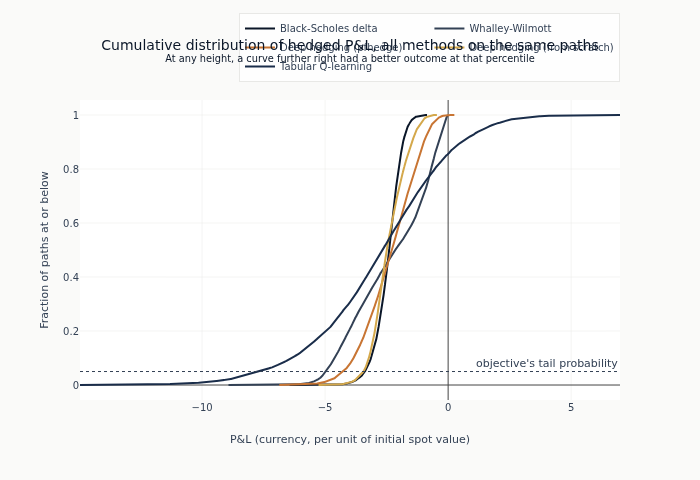

In [23]:
COLOR_BY_METHOD = {
    "Black-Scholes delta": COLORS["blue"],
    "Whalley-Wilmott": COLORS["neutral"],
    "Deep hedging (pfhedge)": COLORS["copper"],
    "Deep hedging (from scratch)": COLORS["amber"],
    "Tabular Q-learning": COLORS["slate"],
}

fig = go.Figure()
for name, values in pnl.items():
    ordered = np.sort(np.asarray(values) * SPOT)
    fig.add_trace(
        go.Scatter(
            x=ordered,
            y=np.arange(1, ordered.size + 1) / ordered.size,
            mode="lines",
            name=name,
            line=dict(color=COLOR_BY_METHOD[name], width=2),
        )
    )
fig.add_hline(
    y=EXPECTED_SHORTFALL_Q,
    line=dict(color=COLORS["neutral"], width=1, dash="dot"),
    annotation_text="objective's tail probability",
)
fig.update_layout(
    title=(
        "Cumulative distribution of hedged P&L, all methods on the same paths"
        "<br><sup>At any height, a curve further right had a better outcome at that "
        "percentile</sup>"
    ),
    xaxis_title="P&L (currency, per unit of initial spot value)",
    yaxis_title="Fraction of paths at or below",
    height=480,
    legend=dict(orientation="h", yanchor="bottom", y=1.06, xanchor="right", x=1),
)
show_plotly_with_alt(
    fig,
    "One empirical cumulative distribution curve per hedging method over the terminal profit and loss of the evaluation paths, with a dotted horizontal line at the objective's tail probability.",
)

### The same distributions as boxes

The cumulative curves separate the tails and compress the middle. A box plot
does the opposite, so the two together say where each method sits overall and
where it sits when things go wrong.

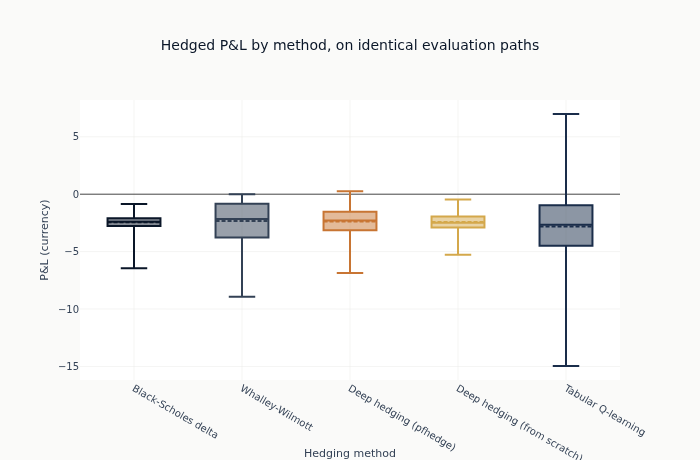

In [24]:
fig = go.Figure()
for name, values in pnl.items():
    fig.add_trace(
        go.Box(
            y=np.asarray(values) * SPOT,
            name=name,
            marker_color=COLOR_BY_METHOD[name],
            boxpoints=False,
            boxmean=True,
        )
    )
fig.update_layout(
    title="Hedged P&L by method, on identical evaluation paths",
    xaxis_title="Hedging method",
    yaxis_title="P&L (currency)",
    height=460,
    showlegend=False,
)
show_plotly_with_alt(
    fig,
    "A box per hedging method over the terminal profit and loss of every evaluation path, with the mean marked.",
)

### The statistics

In [25]:
stats_by_method = {name: pnl_stats(values) for name, values in pnl.items()}
pl.DataFrame(
    [
        {
            "Method": name,
            "Mean P&L": round(stats["mean"], 4),
            "Std dev": round(stats["std"], 4),
            f"Expected shortfall ({EXPECTED_SHORTFALL_Q:.0%})": round(
                stats["expected_shortfall"], 4
            ),
            "Worst path": round(stats["worst_path"], 4),
        }
        for name, stats in stats_by_method.items()
    ]
)

Method,Mean P&L,Std dev,Expected shortfall (5%),Worst path
str,f64,f64,f64,f64
"""Black-Scholes delta""",-2.4488,0.5302,-3.7339,-6.4471
"""Whalley-Wilmott""",-2.3387,1.6112,-5.3616,-8.9262
"""Deep hedging (pfhedge)""",-2.3713,1.0957,-4.7666,-6.8606
"""Deep hedging (from scratch)""",-2.4223,0.6749,-3.7601,-5.2684
"""Tabular Q-learning""",-2.8056,2.7433,-9.0872,-14.9611


## 9. What the hedges do on one path

The statistics say how the distributions differ; this says why. All five
methods are rolled along the same single path, with the price above and the
positions below, so a change in the hedge can be read against the move that
prompted it.

In [26]:
delta_positions = bs_hedger.compute_hedge(eval_option).detach().cpu().numpy()[:, 0, :-1]
ww_positions = ww_hedger.compute_hedge(eval_option).detach().cpu().numpy()[:, 0, :-1]
deep_positions = deep_hedger.compute_hedge(eval_option).detach().cpu().numpy()[:, 0, :-1]
with torch.no_grad():
    scratch_positions = (
        rollout(
            scratch_model,
            eval_option.ul().spot.to(DEVICE),
            eval_option.ul().volatility.to(DEVICE),
        )
        .cpu()
        .numpy()
    )

positions_by_method = {
    "Black-Scholes delta": delta_positions,
    "Whalley-Wilmott": ww_positions,
    "Deep hedging (pfhedge)": deep_positions,
    "Deep hedging (from scratch)": scratch_positions,
    "Tabular Q-learning": qlbs_positions,
}

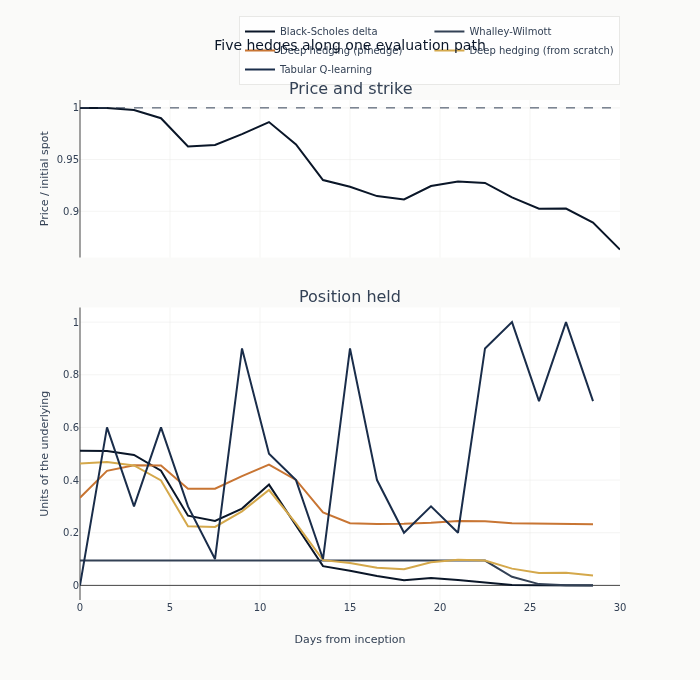

In [27]:
PATH = 0
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    subplot_titles=["Price and strike", "Position held"],
    row_heights=[0.35, 0.65],
    vertical_spacing=0.10,
)
fig.add_trace(
    go.Scatter(
        x=time_days,
        y=eval_spot[PATH],
        line=dict(color=COLORS["blue"], width=2),
        showlegend=False,
    ),
    row=1,
    col=1,
)
fig.add_hline(
    y=PFHEDGE_STRIKE, line=dict(color=COLORS["neutral"], width=1, dash="dash"), row=1, col=1
)
for name, positions in positions_by_method.items():
    series = np.asarray(positions[PATH], dtype=float)
    if not np.isfinite(series).any():
        continue
    fig.add_trace(
        go.Scatter(
            x=time_days[:-1],
            y=series,
            name=name,
            line=dict(color=COLOR_BY_METHOD[name], width=2),
        ),
        row=2,
        col=1,
    )
fig.update_yaxes(title_text="Price / initial spot", row=1, col=1)
fig.update_yaxes(title_text="Units of the underlying", row=2, col=1)
fig.update_xaxes(title_text="Days from inception", row=2, col=1)
fig.update_layout(
    title="Five hedges along one evaluation path",
    height=680,
    legend=dict(orientation="h", yanchor="bottom", y=1.03, xanchor="right", x=1),
)
show_plotly_with_alt(
    fig,
    "Two stacked panels over one evaluation path. Top: the price against a dashed line at the strike. Bottom: the position each of the five hedging methods held over each interval.",
)

## 10. Key takeaways

In [28]:
turnover = {
    name: float(
        np.mean(
            np.abs(
                np.diff(
                    np.concatenate(
                        [np.zeros((positions.shape[0], 1)), np.asarray(positions, dtype=float)],
                        axis=1,
                    ),
                    axis=1,
                )
            ).sum(axis=1)
        )
    )
    for name, positions in positions_by_method.items()
}
turnover_lines = "\n".join(
    f"- **{name}**: expected shortfall "
    f"{stats_by_method[name]['expected_shortfall']:.3f}, standard deviation "
    f"{stats_by_method[name]['std']:.3f}, and {turnover[name]:.2f} units of the underlying "
    f"traded over the option's life."
    for name in positions_by_method
)

display(
    Markdown(f"""
{turnover_lines}

**A hedge is a distribution, not a number.** Once rebalancing is discrete and costly, no
strategy makes the P&L constant, and the only honest comparison is between shapes. Two of the
statistics above describe the middle of the distribution and two describe its left tail; a
method can lead on one pair and trail on the other, and reporting only a mean would hide
exactly the difference the objective was chosen to create.

**Train against the measure you report.** The two deep hedgers minimise the expected shortfall
of terminal P&L, so that is the column their training was aimed at. Neither is optimising the
standard deviation, and neither should be expected to lead on it. The analytical baselines
optimise neither: the delta hedge minimises replication error under assumptions this market
violates, and the Whalley-Wilmott band minimises a cost-adjusted objective in the limit of
small costs.

**Turnover is the mechanism, and it is directly observable.** The whole argument for a
cost-aware hedge is that it trades less, which it pays for by carrying more mismatch between
rebalancing dates. The traded quantity above is that mechanism measured; the tail statistic is
whether the exchange was worth making on these paths.

**Verify a shared convention rather than assuming it.** Three of these methods compute their
P&L outside `pfhedge`. Section 3 checks the two implementations against each other on the same
positions, which costs one assertion and is the only thing standing between this comparison and
a table whose rows were computed by different rules.

### Known limitations

- The market is a simulator with a known generating process. There is no model risk, no jump,
  no gap and no liquidity constraint, and the volatility the hedges read is the true volatility
  rather than an estimate of it.
- Fills are assumed at the modelled price with a fixed proportional cost. A real hedge faces a
  bid-ask spread that varies, and it faces it hardest in precisely the states where a cost-aware
  hedge is most likely to need to trade.
- Every method here is evaluated on one set of {N_PATHS:,} paths from one seed. The seed
  selection in section 5 protects the reported numbers from being tuned on them, but it does not
  turn one evaluation draw into a confidence interval.
- The tabular baseline is coarse by construction: {len(MONEYNESS_BINS)} moneyness bins,
  {len(TIME_BINS)} time bins and {len(HEDGE_LEVELS)} positions. It is here for the contrast
  between learning a value and learning a policy, not as a competitive method.

**Next**: `06_inverse_reinforcement_learning` turns the problem around, and asks what objective
a trader was pursuing given only the trades they made.
""")
)


- **Black-Scholes delta**: expected shortfall -3.734, standard deviation 0.530, and 1.88 units of the underlying traded over the option's life.
- **Whalley-Wilmott**: expected shortfall -5.362, standard deviation 1.611, and 0.57 units of the underlying traded over the option's life.
- **Deep hedging (pfhedge)**: expected shortfall -4.767, standard deviation 1.096, and 0.97 units of the underlying traded over the option's life.
- **Deep hedging (from scratch)**: expected shortfall -3.760, standard deviation 0.675, and 1.55 units of the underlying traded over the option's life.
- **Tabular Q-learning**: expected shortfall -9.087, standard deviation 2.743, and 5.23 units of the underlying traded over the option's life.

**A hedge is a distribution, not a number.** Once rebalancing is discrete and costly, no
strategy makes the P&L constant, and the only honest comparison is between shapes. Two of the
statistics above describe the middle of the distribution and two describe its left tail; a
method can lead on one pair and trail on the other, and reporting only a mean would hide
exactly the difference the objective was chosen to create.

**Train against the measure you report.** The two deep hedgers minimise the expected shortfall
of terminal P&L, so that is the column their training was aimed at. Neither is optimising the
standard deviation, and neither should be expected to lead on it. The analytical baselines
optimise neither: the delta hedge minimises replication error under assumptions this market
violates, and the Whalley-Wilmott band minimises a cost-adjusted objective in the limit of
small costs.

**Turnover is the mechanism, and it is directly observable.** The whole argument for a
cost-aware hedge is that it trades less, which it pays for by carrying more mismatch between
rebalancing dates. The traded quantity above is that mechanism measured; the tail statistic is
whether the exchange was worth making on these paths.

**Verify a shared convention rather than assuming it.** Three of these methods compute their
P&L outside `pfhedge`. Section 3 checks the two implementations against each other on the same
positions, which costs one assertion and is the only thing standing between this comparison and
a table whose rows were computed by different rules.

### Known limitations

- The market is a simulator with a known generating process. There is no model risk, no jump,
  no gap and no liquidity constraint, and the volatility the hedges read is the true volatility
  rather than an estimate of it.
- Fills are assumed at the modelled price with a fixed proportional cost. A real hedge faces a
  bid-ask spread that varies, and it faces it hardest in precisely the states where a cost-aware
  hedge is most likely to need to trade.
- Every method here is evaluated on one set of 10,000 paths from one seed. The seed
  selection in section 5 protects the reported numbers from being tuned on them, but it does not
  turn one evaluation draw into a confidence interval.
- The tabular baseline is coarse by construction: 7 moneyness bins,
  5 time bins and 11 positions. It is here for the contrast
  between learning a value and learning a policy, not as a competitive method.

**Next**: `06_inverse_reinforcement_learning` turns the problem around, and asks what objective
a trader was pursuing given only the trades they made.
